<a href="https://colab.research.google.com/github/NikhilGeorge01/ML-Prac/blob/main/MLAssignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# QUESTION1

In [2]:
# Import and load the parkinsons dataset.
from sklearn.datasets import fetch_openml
data = fetch_openml(name="parkinsons", version=1, as_frame=True)
X = data.data
y = data.target.astype(int)

In [3]:
# Split the dataset into training and testing sets.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

c) objectives of logistic regression with l2 regularization:


L2 Algorithm is Used to penalize large weights by adding a penalty to the mean squared error, for logistic regression log loss is reduced by penalizing mean square error after assigning weights, and so decision boundaries are kept smooth

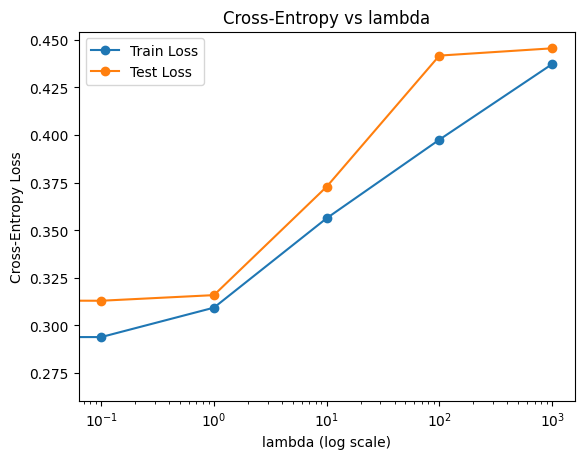

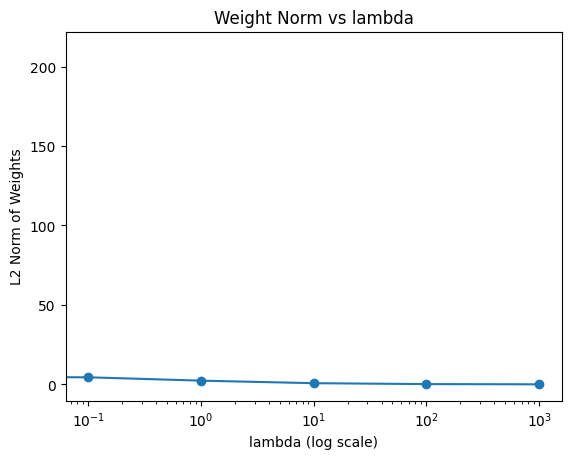

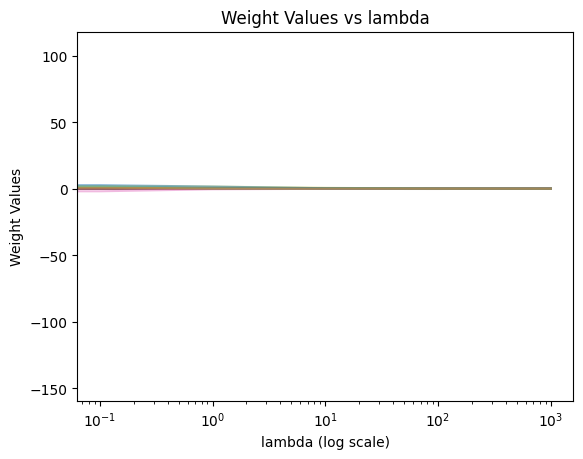

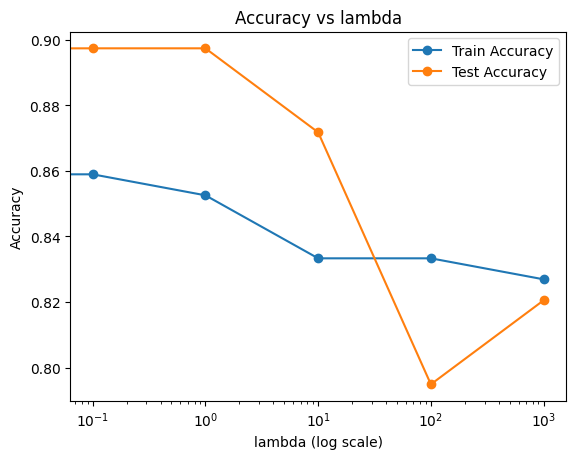

In [5]:
# Train logistic regression models with different L2 regularization strengths and plot results.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, accuracy_score

lambdas = [0, 0.1, 1, 10, 100, 1000]
train_losses, test_losses = [], []
l2_norms, train_accuracies, test_accuracies = [], [], []
weights_list = []
for l in lambdas:
    if l == 0:
        model = LogisticRegression(
            penalty=None, solver="lbfgs", max_iter=10000
        )
    else:
        model = LogisticRegression(
            penalty="l2", C=1/l, solver="lbfgs", max_iter=10000
        )

    model.fit(X_train, y_train)

    train_probabilities = model.predict_proba(X_train)[:, 1]
    test_probabilities = model.predict_proba(X_test)[:, 1]

    train_losses.append(log_loss(y_train, train_probabilities))
    test_losses.append(log_loss(y_test, test_probabilities))

    weights = model.coef_.flatten()
    weights_list.append(weights)
    l2_norms.append(np.linalg.norm(weights, 2))

    train_accuracies.append(accuracy_score(y_train, model.predict(X_train)))
    test_accuracies.append(accuracy_score(y_test, model.predict(X_test)))

plt.plot(lambdas, train_losses, marker='o', label="Train Loss")
plt.plot(lambdas, test_losses, marker='o', label="Test Loss")
plt.xscale("log")
plt.xlabel("lambda (log scale)")
plt.ylabel("Cross-Entropy Loss")
plt.title("Cross-Entropy vs lambda")
plt.legend()
plt.show()

plt.plot(lambdas, l2_norms, marker='o')
plt.xscale("log")
plt.xlabel("lambda (log scale)")
plt.ylabel("L2 Norm of Weights")
plt.title("Weight Norm vs lambda")
plt.show()
weights_array = np.array(weights_list)

for i in range(weights_array.shape[1]):
    plt.plot(lambdas, weights_array[:, i], alpha=0.5)
plt.xscale("log")
plt.xlabel("lambda (log scale)")
plt.ylabel("Weight Values")
plt.title("Weight Values vs lambda")
plt.show()

plt.plot(lambdas, train_accuracies, marker='o', label="Train Accuracy")
plt.plot(lambdas, test_accuracies, marker='o', label="Test Accuracy")
plt.xscale("log")
plt.xlabel("lambda (log scale)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs lambda")
plt.legend()
plt.show()

In [6]:
# Define Gaussian basis functions and transform the data for different sigma values.
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

def gaussian_basis_functions(x, means, sigma):
    return np.exp(-((x - means)**2) / (2 * sigma**2))

sigmas = [0.1, 0.5, 1, 5, 10]
X_train_transformed = {}
X_test_transformed = {}

for sigma in sigmas:
    transformed_features_train = []
    transformed_features_test = []
    for col in X_train.columns:
        means = np.linspace(-10, 10, 5)
        transformed_train = gaussian_basis_functions(X_train[col].values[:, np.newaxis], means, sigma)
        transformed_test = gaussian_basis_functions(X_test[col].values[:, np.newaxis], means, sigma)
        transformed_features_train.append(transformed_train)
        transformed_features_test.append(transformed_test)

    X_train_transformed[sigma] = np.hstack(transformed_features_train)
    X_test_transformed[sigma] = np.hstack(transformed_features_test)

    X_train_transformed[sigma] = np.hstack([np.ones((X_train_transformed[sigma].shape[0], 1)), X_train_transformed[sigma]])
    X_test_transformed[sigma] = np.hstack([np.ones((X_test_transformed[sigma].shape[0], 1)), X_test_transformed[sigma]])

    print("Shape of transformed training data for sigma=", sigma, ": ", X_train_transformed[sigma].shape)
    print("Shape of transformed testing data for sigma=", sigma, ": ", X_test_transformed[sigma].shape)

Shape of transformed training data for sigma= 0.1 :  (156, 111)
Shape of transformed testing data for sigma= 0.1 :  (39, 111)
Shape of transformed training data for sigma= 0.5 :  (156, 111)
Shape of transformed testing data for sigma= 0.5 :  (39, 111)
Shape of transformed training data for sigma= 1 :  (156, 111)
Shape of transformed testing data for sigma= 1 :  (39, 111)
Shape of transformed training data for sigma= 5 :  (156, 111)
Shape of transformed testing data for sigma= 5 :  (39, 111)
Shape of transformed training data for sigma= 10 :  (156, 111)
Shape of transformed testing data for sigma= 10 :  (39, 111)


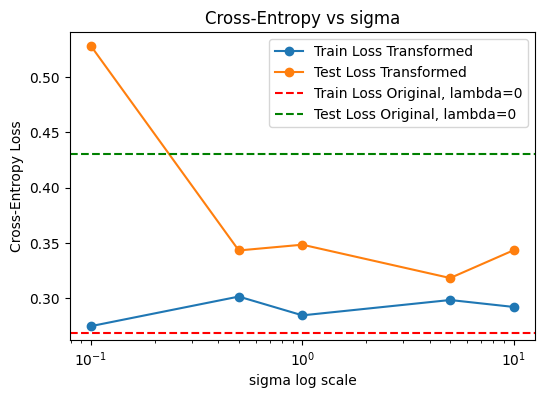

In [7]:
# Train logistic regression models on transformed data and plot results.
train_losses_transformed, test_losses_transformed = [], []

for sigma in sigmas:
    model = LogisticRegression(penalty=None, solver="lbfgs", max_iter=10000)
    model.fit(X_train_transformed[sigma], y_train)

    y_train_prob_transformed = model.predict_proba(X_train_transformed[sigma])[:, 1]
    y_test_prob_transformed = model.predict_proba(X_test_transformed[sigma])[:, 1]

    train_losses_transformed.append(log_loss(y_train, y_train_prob_transformed))
    test_losses_transformed.append(log_loss(y_test, y_test_prob_transformed))

plt.figure(figsize=(6,4))
plt.plot(sigmas, train_losses_transformed, marker='o', label="Train Loss (Transformed)")
plt.plot(sigmas, test_losses_transformed, marker='o', label="Test Loss (Transformed)")
plt.axhline(y=train_losses[0], color='r', linestyle='--', label="Train Loss (Original, λ=0)")
plt.axhline(y=test_losses[0], color='g', linestyle='--', label="Test Loss (Original, λ=0)")
plt.xscale("log")
plt.xlabel("σ (log scale)")
plt.ylabel("Cross-Entropy Loss")
plt.title("Cross-Entropy vs σ")
plt.legend()
plt.show()

Smaller values of sigma lead to more localized basis functions, increasing model complexity and potentially causing overfitting . Larger values of σ lead to smoother basis functions, reducing complexity and potentially increasing bias , demonstrating the bias-variance trade-off.

In [10]:
# Concatenate transformed training and testing data across different sigma values.
X_train_concat = []
X_test_concat = []

for sigma in sigmas:
    X_train_concat.append(X_train_transformed[sigma])
    X_test_concat.append(X_test_transformed[sigma])

X_train_combined = np.hstack(X_train_concat)
X_test_combined = np.hstack(X_test_concat)

print("Shape of combined transformed training data:", X_train_combined.shape)
print("Shape of combined transformed testing data:", X_test_combined.shape)

Shape of combined transformed training data: (156, 555)
Shape of combined transformed testing data: (39, 555)


In [11]:
# Train regularized logistic regression models on the combined transformed data.
lambdas_transformed = [0, 0.1, 1, 10, 100, 1000, 10000]
train_losses_transformed_reg = []
test_losses_transformed_reg = []
l2_norms_transformed_reg = []

for l in lambdas_transformed:
    if l == 0:
        model = LogisticRegression(penalty=None, solver="lbfgs", max_iter=10000)
    else:
        model = LogisticRegression(penalty="l2", C=1/l, solver="lbfgs", max_iter=10000)

    model.fit(X_train_combined, y_train)

    y_train_prob_transformed_reg = model.predict_proba(X_train_combined)[:, 1]
    y_test_prob_transformed_reg = model.predict_proba(X_test_combined)[:, 1]

    train_losses_transformed_reg.append(log_loss(y_train, y_train_prob_transformed_reg))
    test_losses_transformed_reg.append(log_loss(y_test, y_test_prob_transformed_reg))

    w_transformed_reg = model.coef_.flatten()
    l2_norms_transformed_reg.append(np.linalg.norm(w_transformed_reg, 2))

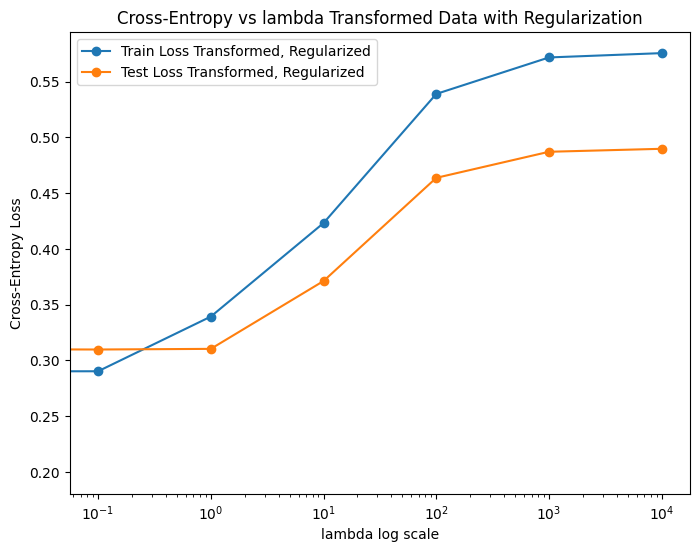

In [12]:
# Plot cross-entropy loss vs lambda for transformed and regularized data.
plt.figure(figsize=(8, 6))
plt.plot(lambdas_transformed, train_losses_transformed_reg, marker='o', label="Train Loss Transformed, Regularized")
plt.plot(lambdas_transformed, test_losses_transformed_reg, marker='o', label="Test Loss Transformed, Regularized")
plt.xscale("log")
plt.xlabel("lambda log scale")
plt.ylabel("Cross-Entropy Loss")
plt.title("Cross-Entropy vs lambda Transformed Data with Regularization")
plt.legend()
plt.show()

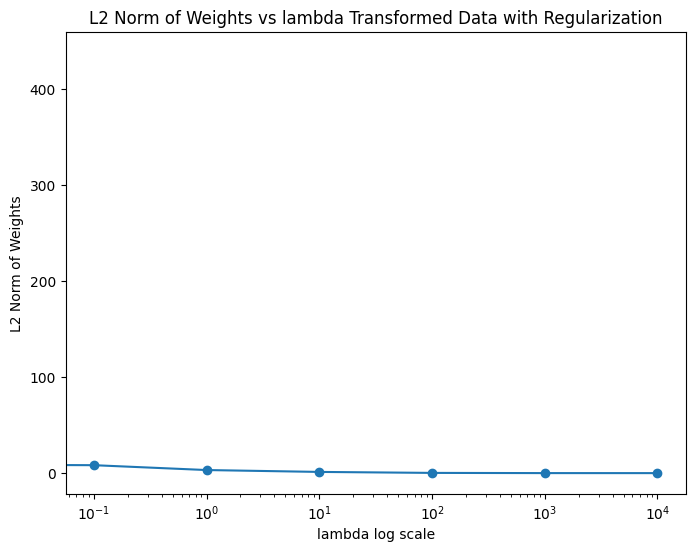

In [13]:
# Plot L2 norm of weights vs lambda for transformed and regularized data.
plt.figure(figsize=(8, 6))
plt.plot(lambdas_transformed, l2_norms_transformed_reg, marker='o')
plt.xscale("log")
plt.xlabel("lambda log scale")
plt.ylabel("L2 Norm of Weights")
plt.title("L2 Norm of Weights vs lambda Transformed Data with Regularization")
plt.show()

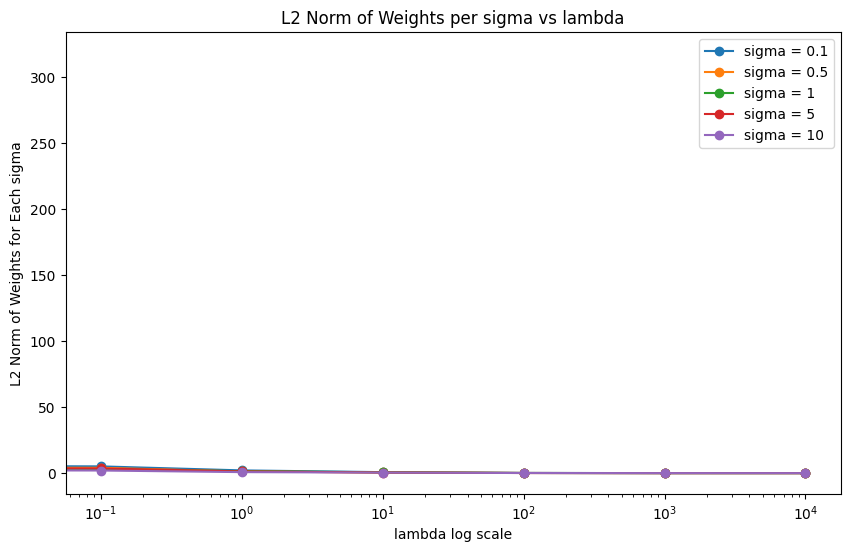

In [14]:
# Plot L2 norm of weights per sigma vs lambda for transformed and regularized data.
l2_norms_per_sigma = {sigma: [] for sigma in sigmas}

for l in lambdas_transformed:
    if l == 0:
        model = LogisticRegression(penalty=None, solver="lbfgs", max_iter=10000)
    else:
        model = LogisticRegression(penalty="l2", C=1/l, solver="lbfgs", max_iter=10000)

    model.fit(X_train_combined, y_train)

    feature_start_index = 0
    for i, sigma in enumerate(sigmas):
        num_features_per_sigma = 1 + 5 * X_train.shape[1]
        feature_end_index = feature_start_index + num_features_per_sigma

        weights_sigma = model.coef_.flatten()[feature_start_index + 1 : feature_end_index]

        l2_norms_per_sigma[sigma].append(np.linalg.norm(weights_sigma, 2))

        feature_start_index = feature_end_index

plt.figure(figsize=(10, 6))
for sigma in sigmas:
    plt.plot(lambdas_transformed, l2_norms_per_sigma[sigma], marker='o', label=f'sigma = {sigma}')

plt.xscale("log")
plt.xlabel("lambda log scale")
plt.ylabel("L2 Norm of Weights for Each sigma")
plt.title("L2 Norm of Weights per sigma vs lambda")
plt.legend()
plt.show()

# QUESTION2

In [15]:
# Load the iris dataset and assign feature and target variables.
from sklearn.datasets import load_iris

iris_data = load_iris()

X = iris_data.data
y = iris_data.target

In [16]:
# Prepare the iris dataset for linear regression.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

X_df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(X.shape[1])])

y_regression = X_df['feature_0']

X_regression = X_df.drop('feature_0', axis=1)

X_regression_train, X_regression_test, y_regression_train, y_regression_test = train_test_split(
    X_regression, y_regression, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_regression_train_scaled = scaler.fit_transform(X_regression_train)
X_regression_test_scaled = scaler.transform(X_regression_test)

print("Shapes after splitting and scaling:")
print("X_regression_train_scaled:", X_regression_train_scaled.shape)
print("X_regression_test_scaled:", X_regression_test_scaled.shape)
print("y_regression_train:", y_regression_train.shape)
print("y_regression_test:", y_regression_test.shape)

Shapes after splitting and scaling:
X_regression_train_scaled: (120, 3)
X_regression_test_scaled: (30, 3)
y_regression_train: (120,)
y_regression_test: (30,)


In [21]:
# Train and evaluate a Linear Regression model.
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

linear_regression_model = LinearRegression()

linear_regression_model.fit(X_regression_train_scaled, y_regression_train)

y_regression_pred = linear_regression_model.predict(X_regression_test_scaled)

mse = mean_squared_error(y_regression_test, y_regression_pred)

r2 = r2_score(y_regression_test, y_regression_pred)

print("Mean Squared Error (MSE):", mse)
print("R-squared (R2):", r2)

Mean Squared Error (MSE): 0.10212647866320375
R-squared (R2): 0.8520477902310164


In [22]:
# Train and evaluate Ridge and Lasso Regression models.
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

ridge_model = Ridge(alpha=1.0)
lasso_model = Lasso(alpha=0.1)

ridge_model.fit(X_regression_train_scaled, y_regression_train)
lasso_model.fit(X_regression_train_scaled, y_regression_train)

y_ridge_pred = ridge_model.predict(X_regression_test_scaled)
y_lasso_pred = lasso_model.predict(X_regression_test_scaled)

mse_ridge = mean_squared_error(y_regression_test, y_ridge_pred)
r2_ridge = r2_score(y_regression_test, y_ridge_pred)

mse_lasso = mean_squared_error(y_regression_test, y_lasso_pred)
r2_lasso = r2_score(y_regression_test, y_lasso_pred)

print("Ridge Regression:")
print("  Mean Squared Error (MSE):", mse_ridge)
print("  R-squared (R2):", r2_ridge)

print("\nLasso Regression:")
print("  Mean Squared Error (MSE):", mse_lasso)
print("  R-squared (R2):", r2_lasso)

Ridge Regression:
  Mean Squared Error (MSE): 0.09363860271269377
  R-squared (R2): 0.8643443074473242

Lasso Regression:
  Mean Squared Error (MSE): 0.12157358128102438
  R-squared (R2): 0.8238744717775386


In [23]:
# Prepare the iris dataset for classification.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler_cls = StandardScaler()

X_train_cls_scaled = scaler_cls.fit_transform(X_train_cls)
X_test_cls_scaled = scaler_cls.transform(X_test_cls)

print("Shapes after splitting and scaling for classification:")
print("X_train_cls_scaled:", X_train_cls_scaled.shape)
print("X_test_cls_scaled:", X_test_cls_scaled.shape)
print("y_train_cls:", y_train_cls.shape)
print("y_test_cls:", y_test_cls.shape)

Shapes after splitting and scaling for classification:
X_train_cls_scaled: (120, 4)
X_test_cls_scaled: (30, 4)
y_train_cls: (120,)
y_test_cls: (30,)


In [24]:
# Evaluate the logistic regression model on the test data.
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

logistic_regression_model = LogisticRegression(max_iter=1000)

logistic_regression_model.fit(X_train_cls_scaled, y_train_cls)

y_cls_pred = logistic_regression_model.predict(X_test_cls_scaled)

accuracy = accuracy_score(y_test_cls, y_cls_pred)
precision = precision_score(y_test_cls, y_cls_pred, average='weighted')
recall = recall_score(y_test_cls, y_cls_pred, average='weighted')
f1 = f1_score(y_test_cls, y_cls_pred, average='weighted')

print("Logistic Regression Performance:")
print("  Accuracy:", accuracy)
print("  Precision:", precision)
print("  Recall:", recall)
print("  F1-score:", f1)

Logistic Regression Performance:
  Accuracy: 1.0
  Precision: 1.0
  Recall: 1.0
  F1-score: 1.0
